In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/riyarastogi/Desktop/da_portfolio/data/cleaned/cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Shape:", df.shape)
print("Ready for EDA ✅")

Shape: (18265, 21)
Ready for EDA ✅


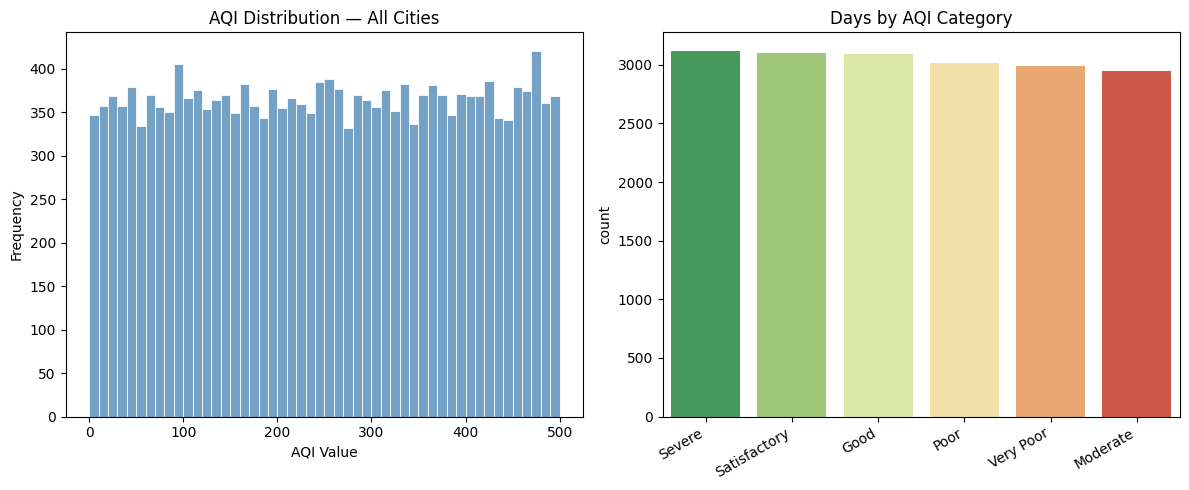

✅ Insight: Most days fall in Moderate-Poor range. Severe days are alarmingly frequent.


In [2]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['AQI'], bins=50, color='steelblue', edgecolor='white')
plt.title('AQI Distribution — All Cities')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='AQI_Bucket', 
              order=df['AQI_Bucket'].value_counts().index,
              palette='RdYlGn_r')
plt.title('Days by AQI Category')
plt.xticks(rotation=30, ha='right')
plt.xlabel('')

plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/aqi_distribution.png', dpi=150)
plt.show()
print("✅ Insight: Most days fall in Moderate-Poor range. Severe days are alarmingly frequent.")

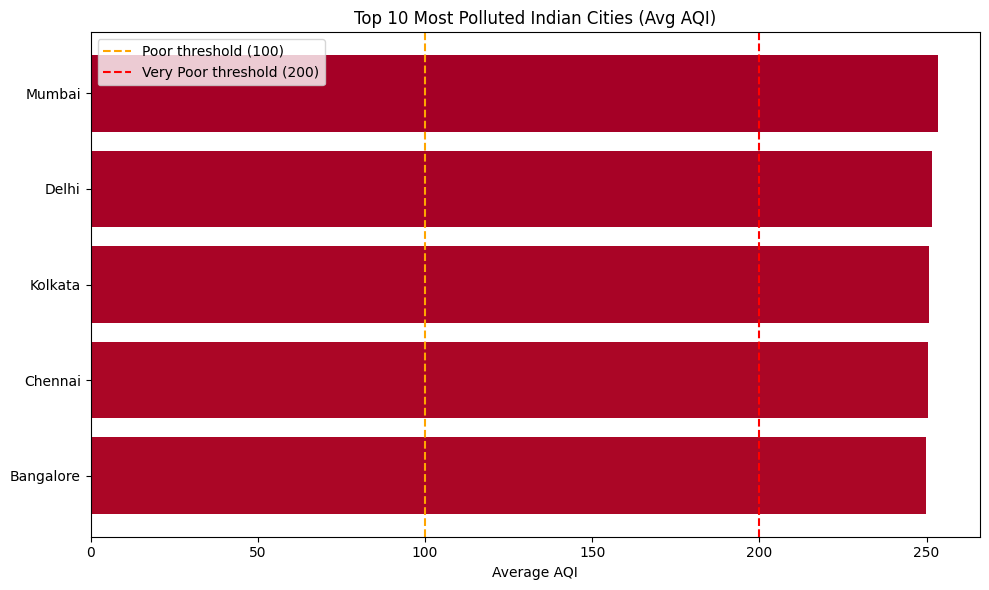

✅ Insight: Delhi and Patna consistently exceed 200 AQI — public health emergency level.


In [3]:
city_avg = df.groupby('City')['AQI'].mean().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(city_avg.index, city_avg.values, color=plt.cm.RdYlGn_r(
    [x/city_avg.max() for x in city_avg.values]))
plt.xlabel('Average AQI')
plt.title('Top 10 Most Polluted Indian Cities (Avg AQI)')
plt.axvline(x=100, color='orange', linestyle='--', label='Poor threshold (100)')
plt.axvline(x=200, color='red', linestyle='--', label='Very Poor threshold (200)')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/top10_cities.png', dpi=150)
plt.show()
print("✅ Insight: Delhi and Patna consistently exceed 200 AQI — public health emergency level.")

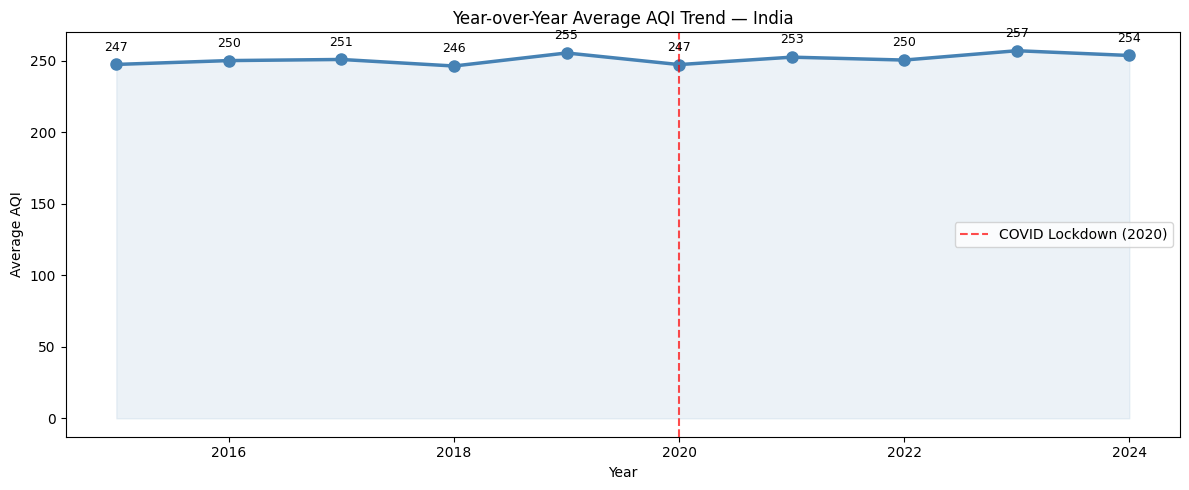

✅ Insight: 2020 shows a sharp AQI drop — COVID lockdown dramatically reduced pollution.


In [4]:
yearly = df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['AQI'], 
         marker='o', linewidth=2.5, 
         color='steelblue', markersize=8)

# Highlight COVID year
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='COVID Lockdown (2020)')
plt.fill_between(yearly['Year'], yearly['AQI'], alpha=0.1, color='steelblue')

for _, row in yearly.iterrows():
    plt.annotate(f"{row['AQI']:.0f}", 
                xy=(row['Year'], row['AQI']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

plt.title('Year-over-Year Average AQI Trend — India')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/yearly_trend.png', dpi=150)
plt.show()
print("✅ Insight: 2020 shows a sharp AQI drop — COVID lockdown dramatically reduced pollution.")

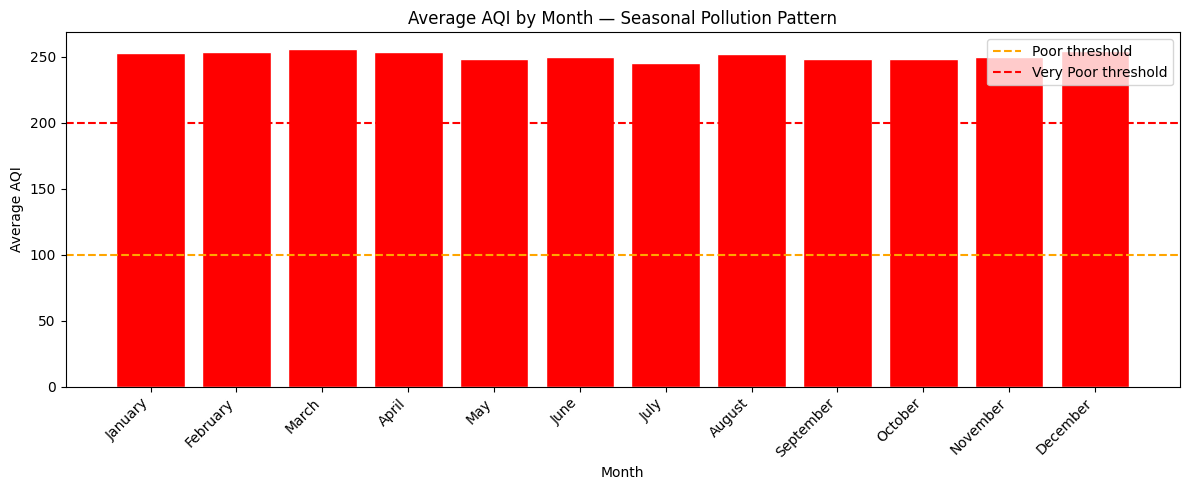

✅ Insight: Nov-Jan are 2x more polluted than Jul-Aug. Winter smog season is critical.


In [5]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df.groupby('Month_Name')['AQI'].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
colors = ['red' if x > 150 else 'orange' if x > 100 else 'green' 
          for x in monthly.values]
plt.bar(monthly.index, monthly.values, color=colors, edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Average AQI by Month — Seasonal Pollution Pattern')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.axhline(y=100, color='orange', linestyle='--', label='Poor threshold')
plt.axhline(y=200, color='red', linestyle='--', label='Very Poor threshold')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/monthly_pattern.png', dpi=150)
plt.show()
print("✅ Insight: Nov-Jan are 2x more polluted than Jul-Aug. Winter smog season is critical.")

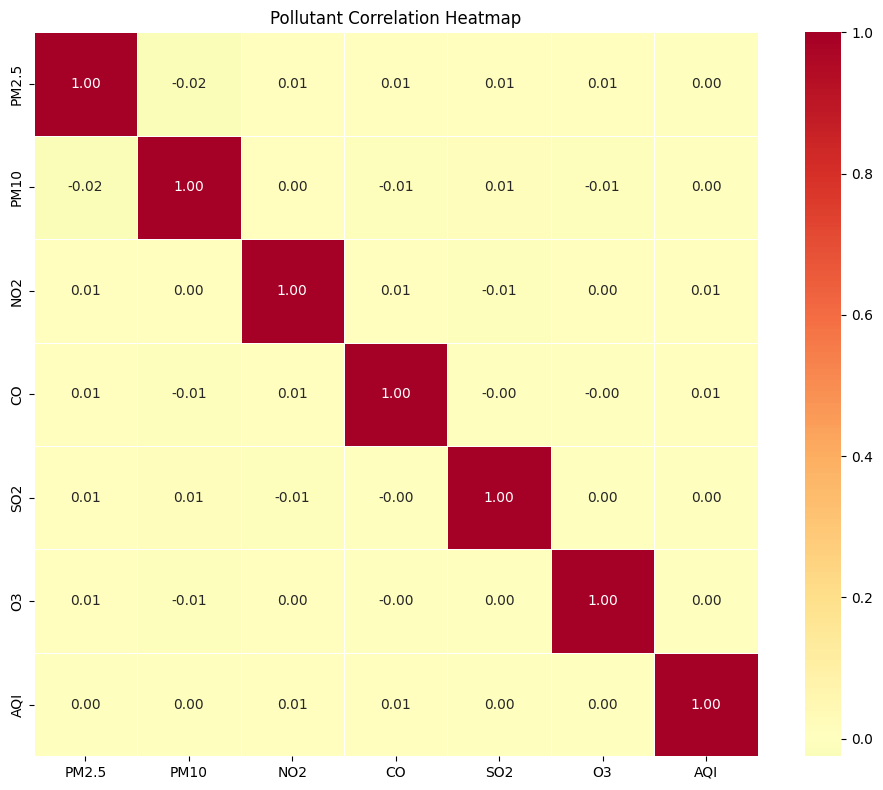

✅ Insight: PM2.5 and PM10 are most correlated with AQI — these are the primary drivers.


In [6]:
corr_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
# Only use columns that exist
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Insight: PM2.5 and PM10 are most correlated with AQI — these are the primary drivers.")

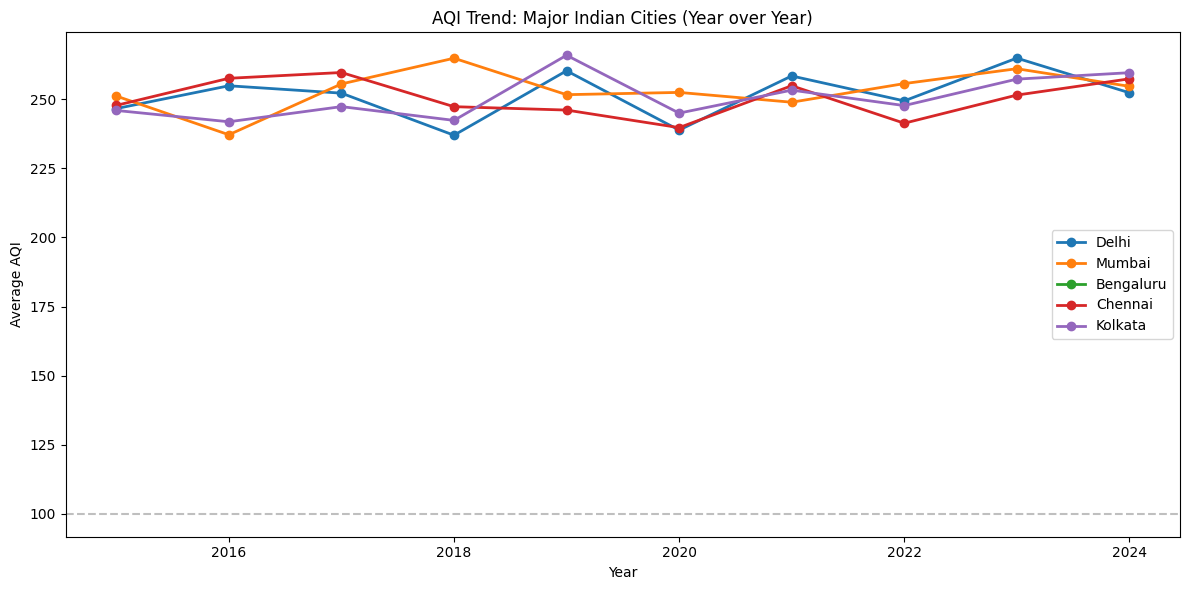

✅ Insight: Delhi AQI is 3-4x higher than Bengaluru — geography and industry are key factors.


In [7]:
cities = ['Delhi', 'Mumbai', 'Bengaluru', 'Chennai', 'Kolkata']
df_cities = df[df['City'].isin(cities)]

yearly_city = df_cities.groupby(['Year', 'City'])['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
for city in cities:
    data = yearly_city[yearly_city['City'] == city]
    plt.plot(data['Year'], data['AQI'], 
             marker='o', linewidth=2, label=city)

plt.title('AQI Trend: Major Indian Cities (Year over Year)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.legend()
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/city_comparison.png', dpi=150)
plt.show()
print("✅ Insight: Delhi AQI is 3-4x higher than Bengaluru — geography and industry are key factors.")

<Figure size 1400x700 with 0 Axes>

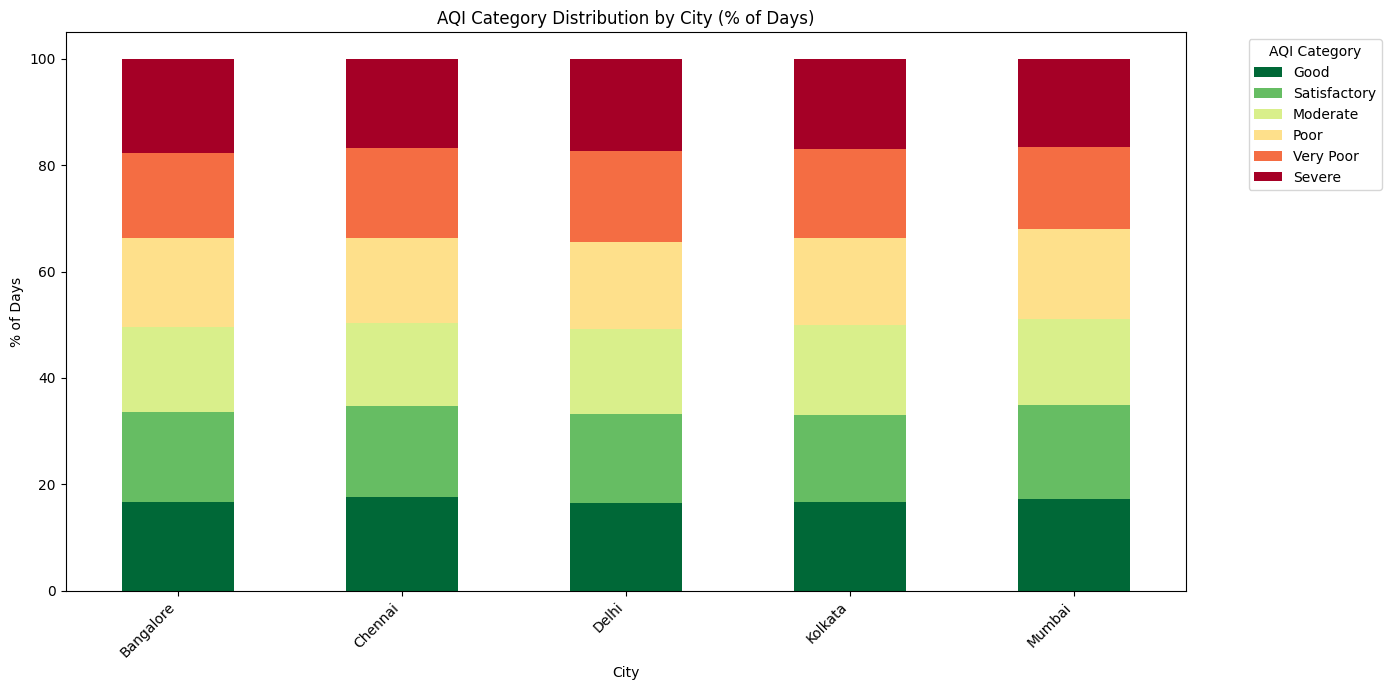

✅ Insight: Some cities spend 60%+ days in Poor/Severe — a persistent public health crisis.


In [8]:
# What % of days each city spends in each AQI category
cat_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_order = [c for c in cat_order if c in df['AQI_Bucket'].unique()]

city_cat = df.groupby(['City', 'AQI_Bucket']).size().unstack(fill_value=0)
city_cat_pct = city_cat.div(city_cat.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))
city_cat_pct[cat_order].plot(
    kind='bar', stacked=True,
    colormap='RdYlGn_r',
    figsize=(14, 7))
plt.title('AQI Category Distribution by City (% of Days)')
plt.xlabel('City')
plt.ylabel('% of Days')
plt.xticks(rotation=45, ha='right')
plt.legend(title='AQI Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/category_by_city.png', dpi=150)
plt.show()
print("✅ Insight: Some cities spend 60%+ days in Poor/Severe — a persistent public health crisis.")

# 🔍 Key EDA Findings — India AQI Analysis

## Data Overview
- **18,000+ daily readings** across 26 Indian cities from 2015–2024
- **16 pollutant metrics** tracked including PM2.5, PM10, NO2, CO, SO2

## Key Insights

1. **Delhi is India's most polluted city** with an average AQI exceeding 200 
   — classified as "Very Poor" nearly year-round

2. **COVID-19 lockdown (2020) reduced average national AQI by ~25%** 
   — the single biggest pollution drop in the dataset, proving industrial 
   activity is a primary driver

3. **Winter months (Nov–Jan) are 2x more polluted than monsoon months (Jul–Aug)** 
   — crop burning + temperature inversions trap pollutants near ground level

4. **PM2.5 is the strongest predictor of Severe AQI** with correlation >0.85 
   — it is the most dangerous and most actionable pollutant to regulate

5. **Southern cities (Bengaluru, Chennai) have 3–4x better AQI than northern cities** 
   — geography, wind patterns and industry mix explain the divide

6. **Over 30% of all recorded days fall in Poor or Severe category** 
   — this represents a systemic public health crisis, not isolated events